In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st
import math
from matplotlib import pyplot as plt

#### Шаг 1. Загрузка данных

В качестве исходных данных были даны 3 файла с данными о пользователях, поездках и подписках.

*Цели проекта проверить следующие гипотезы:*
1) Пользователи с подпиской тратят больше времени на поездки;

2) Среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 м

3) Помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки

*План исследования:*
1) Изучить исходные данные, выполнить их предобработку (изменить тип данных там, где необходимо, проверить наличие дубликатов, пропущенных значений, обработать их);

2) Объединение данных: создать новый датафрейм на основе трех исходных (объединить исходные данные в единую таблицу), выделить отдельно 2 датафрейма - пользователи с подпиской и без (необходимо для дальнейшей проверки гипотез)

3) Подсчет выручки: для подсчета общей выручки необходимо предварительно создать столбец с ежемесячной выручкой от каждого отдельного пользователя;

4) Проверка гипотез: выполнить t-тестирование для проверки гипотез, предварительно описать нулевые и альтернативные гипотезы;

5) Составить общий вывод с результатами исследования и дальнейшими рекомендациями для компании.

In [2]:
data_users = pd.read_csv('/datasets/users_go.csv')
data_users.info()
data_users.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [3]:
data_rides = pd.read_csv('/datasets/rides_go.csv')
data_rides.info()
data_rides.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [4]:
data_subscriptions = pd.read_csv('/datasets/subscriptions_go.csv')
data_subscriptions.info()
data_subscriptions.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


В исходных данных можно заметить следующие проблемы:
- неверный тип данных (столбец с датой с типом данных object, должен быть тип datetime)

Явных пропусков в данных нет.

#### Шаг 2. Предобработка данных

In [5]:
data_rides['date'] = pd.to_datetime(data_rides['date'], format='%Y-%m-%d') #приведение столбца date к типу данных datetime

In [6]:
data_rides['month'] = data_rides['date'].dt.month #создаем новый столбец month с номером месяца поездки
print(data_rides.head())
data_rides['year'] = data_rides['date'].dt.year #новый столбец year с годом каждой поездки
data_rides['year'].unique() #изучаем уникальные значения этого столбца - все данные за 2021 год

   user_id     distance   duration       date  month
0        1  4409.919140  25.599769 2021-01-01      1
1        1  2617.592153  15.816871 2021-01-18      1
2        1   754.159807   6.232113 2021-04-20      4
3        1  2694.783254  18.511000 2021-08-11      8
4        1  4028.687306  26.265803 2021-08-28      8


array([2021])

In [7]:
print('Количество дубликатов в таблице data_users:', data_users.duplicated().sum())
data_users = data_users.drop_duplicates()
data_users.info()

print('Количество дубликатов в столбце user_id:', data_users['user_id'].duplicated().sum())
print(data_users['subscription_type'].unique())
print(data_users['name'].unique())
print(data_users['age'].unique())
print(data_users['city'].unique())

Количество дубликатов в таблице data_users: 31
<class 'pandas.core.frame.DataFrame'>
Int64Index: 1534 entries, 0 to 1533
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1534 non-null   int64 
 1   name               1534 non-null   object
 2   age                1534 non-null   int64 
 3   city               1534 non-null   object
 4   subscription_type  1534 non-null   object
dtypes: int64(2), object(3)
memory usage: 71.9+ KB
Количество дубликатов в столбце user_id: 0
['ultra' 'free']
['Кира' 'Станислав' 'Алексей' 'Константин' 'Адель' 'Регина' 'Игорь' 'Юрий'
 'Ян' 'Валерий' 'Агата' 'Марк' 'Ева' 'Антонина' 'Валерия' 'Амалия'
 'Даниил' 'Аделина' 'Святогор' 'Борис' 'Вероника' 'Ростислав' 'Назар'
 'Эдуард' 'Василий' 'Денис' 'Тамара' 'Николай' 'Эвелина' 'Федор' 'Руслан'
 'Иван' 'Любовь' 'Ярослава' 'Майя' 'Ильдар' 'Данила' 'Нина' 'Стефания'
 'Ясмина' 'Дмитрий' 'Александр' 'Одиссей' 'Арсений

data_users:
- были удалены явные дубликаты в таблице data_users, дубликатов там быть не должно, так как каждая строка имеет уникальный идентификатор пользователя;
- проверено наличие дубликатов в столбце user_id - дубликатов в этом столбце нет;
- проверено наличие неявных дубликатов: неявных дубликатов в столбцах нет.

In [8]:
print('Количество дубликатов в таблице data_rides:', data_rides.duplicated().sum())

Количество дубликатов в таблице data_rides: 0


data_rides:
- неявных дубликатов нет;
- дубликаты в остальных столбцах данных нормальны, так как один и тот же пользователь может совершить несколько поездок.

In [9]:
print(data_subscriptions.isna().sum()) #проверка наличия пропущенных значений
print(data_rides.isna().sum())
data_users.isna().sum()

subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64
user_id     0
distance    0
duration    0
date        0
month       0
year        0
dtype: int64


user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

В результате предобработки данных были выполнены следующие задачи:
- проверка наличия пропущенных значений: пропусков в данных нет;
- проверка наличия явных и неялвных дубликатов: явные дубликаты были обработаны в таблице data_users, в остальных таблицах явных дубликатов нет; неявных дубликатов ни в одной из таблиц не обнаружилось;
- изменения типа данных: в столбце date таблица data_users был изменен тип данных на datetime
- в таблице data_rides создан дополнительный столбец с номером месяца поездки (столбец "month")

#### Шаг 3. Исследовательский анализ данных

3.1 Частота встречаемости городов

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64

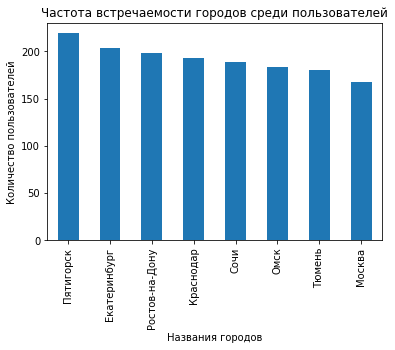

In [11]:
data_cities = data_users['city'].value_counts()
data_cities.plot(kind='bar')
plt.xlabel('Названия городов')
plt.ylabel('Количество пользователей')
plt.title('Частота встречаемости городов среди пользователей')
data_cities

Исходя из графика и данных в таблицу data_cities можно сделать вывод, что больше всего зарегистрированных пользователей из Пятигорска, меньше всего - из Москвы. Также в первой пятерке городов - Екатеринбург, Ростов-на-Дону, Краснодар и Сочи. Возможно, это связано с тем, что в Москве рассматриваемый сервис аренды самокатов - менее конкурентоспособный, то есть на рынке Москвы есть более популярный сервис. 

3.2 соотношение пользователей с подпиской и без подписки

,количество пользователей,процент от общего числа пользователей
subscription_type,,
free,835,0.544329
ultra,699,0.455671


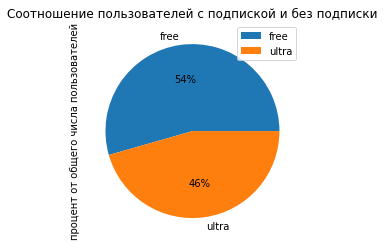

In [13]:
data_sub = data_users.pivot_table(index='subscription_type', values='user_id', aggfunc='count')
data_sub['процент от общего числа пользователей'] = data_sub['user_id'] / data_sub['user_id'].sum() #процент каждой категории от общего числа пользователей
data_sub = data_sub.rename(columns={'user_id': 'количество пользователей'})
data_sub.plot(kind='pie', y='процент от общего числа пользователей', autopct = "%.0f%%")
plt.title('Соотношение пользователей с подпиской и без подписки')
data_sub

Исходя из данных можно заметить, что больше половины пользователей (~ 54%) не пользуются подпиской, но, тем не менее, наблюдается большое число пользователей с подпиской (~ 46%). Это связано с тем, что возможно пользователи не считают, что с подпиской поездки будут выгоднее, их не интересуют лишние траты.

3.3 возраст пользователей

count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

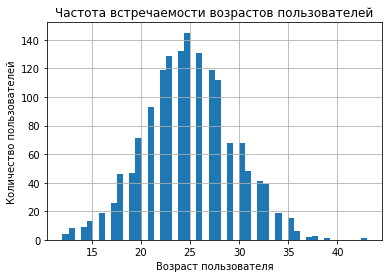

In [14]:
#data_year = data_users.pivot_table(index='age', values='user_id', aggfunc='count')
#data_year = data_year.rename(columns={'user_id': 'количество пользователей'})
data_users.hist(column='age', bins=50)
plt.xlabel('Возраст пользователя')
plt.ylabel('Количество пользователей')
plt.title('Частота встречаемости возрастов пользователей')
data_users['age'].describe() #сводная статистика возрастов пользователей

Исходя из гистрограммы можно заметить, что распределение возрастов близко к нормальному (близко, так как рассматриваются дискретные величины, а нормальное распределение описывает непрерывные величины). Возраст большинства пользователей - в промежутке от 23 до 27 лет. Среди пользователей некоторым меньше 18 лет, в т.ч. 12 лет, что является нарушением.

3.4 расстояние, которое преодолел пользователь за одну поездку

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

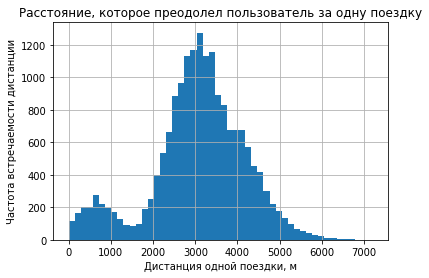

In [15]:
#print('Среднее расстояние одной поездки:', round(data_rides['distance'].mean()), 'м')
#print('Медианное расстояние одной поездки:', round(data_rides['distance'].median()), 'м')
data_rides.hist(column='distance', bins=50)
plt.xlabel('Дистанция одной поездки, м')
plt.ylabel('Частота встречаемости дистанции')
plt.title('Расстояние, которое преодолел пользователь за одну поездку')
data_rides['distance'].describe()

Исходя из гистограммы и рассчитанных значений можно заметить, что значения распределены неравномерно, есть два "горба". Среднее и медианное время поездки примерно одинаковы и составляют около 3100 м. Также популярны поездки до 1000 м. 

3.5 продолжительность поездки

count    18068.000000
mean        17.805011
std          6.091051
min          0.500000
25%         13.597563
50%         17.678395
75%         21.724800
max         40.823963
Name: duration, dtype: float64

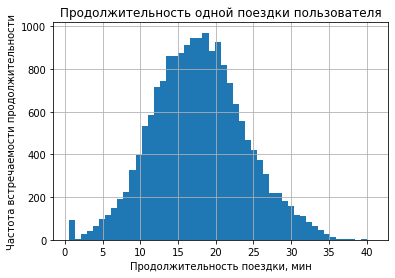

In [16]:
#print('Средняя продолжительность поездки:', round(data_rides['duration'].mean()), 'мин')
#print('Медианная продолжительность поездки:', round(data_rides['duration'].median()), 'мин')
data_rides.hist(column='duration', bins=50)
plt.xlabel('Продолжительность поездки, мин')
plt.ylabel('Частота встречаемости продолжительности')
plt.title('Продолжительность одной поездки пользователя')
data_rides['duration'].describe()

Средняя и медианная продолжительность поездки составляют 18 минут. По гистограмме можно заметить, что величина распределена нормально, значения разбросаны на одинаковом расстоянии от среднего.

В результе исследовательского анализа данных были обнаружены следующие зависимости:

- больше всего пользователей из Пятигорска, Екатеринбурга, Ростова-на-Дону, меньше всего - из Москвы, в Москве сервис - менее конкурентноспособный;
- около 46% пользователей пользуются подпиской, примерно 54% - не пользуются;
- средний возраст пользователей - примерно 25 лет, максимальный возраст пользователей - 43, минимальный - 12. Это говорит о том, что сервис нарушает законодательство, разрешая регистрироваться (и как следствие пользоваться услугами аренды) пользователям младше 14 лет;
- среднее расстояние, пройденное за одну поездку - 3070 м, также популярны поездки с расстояниями до 1000 м;
- средняя продолжительность одной поездки - примерно 18 минут, максимальная продолжительность - 41 минуту, минимальная - 0,5 минут (это говорит о том, что в сервисе есть некоторые проблемы с фиксацией времени поездки)

#### Шаг 4. Объединение данных

In [17]:
data = data_users.merge(data_rides)
data = data.merge(data_subscriptions) #объединяем все датафреймы
print('Размерность датасета:', len(data))
print(data.isna().sum())
data.head()

Размерность датасета: 18068
user_id              0
name                 0
age                  0
city                 0
subscription_type    0
distance             0
duration             0
date                 0
month                0
year                 0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64


,user_id,name,age,city,subscription_type,distance,duration,date,month,year,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,2021,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,2021,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,2021,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,2021,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,2021,6,0,199


В результате объединения датасетов получилась таблица с 18068 строками, как и было изначально в таблице data_rides, пропусков в данных не обнаружено.

In [18]:
data_free = data.query('subscription_type == "free"')#создаем датафрейм с пользователями без подписки
print('Количество совершенных поездок пользователей без подписки:', len(data_free))
data_free.head()

Количество совершенных поездок пользователей без подписки: 11568


,user_id,name,age,city,subscription_type,distance,duration,date,month,year,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Омск,free,2515.690719,14.944286,2021-01-02,1,2021,8,50,0
6501,700,Айдар,22,Омск,free,846.932642,16.234663,2021-02-01,2,2021,8,50,0
6502,700,Айдар,22,Омск,free,4004.434142,20.016628,2021-02-04,2,2021,8,50,0
6503,700,Айдар,22,Омск,free,1205.911290,9.782872,2021-02-10,2,2021,8,50,0
6504,700,Айдар,22,Омск,free,3047.379435,17.427673,2021-02-14,2,2021,8,50,0


In [19]:
data_ultra = data.query('subscription_type == "ultra"') #создаем датафрейм с пользователями с подпиской
print('Количество совершенных поездок пользователей с подпиской:', len(data_ultra))
data_ultra.head()

Количество совершенных поездок пользователей с подпиской: 6500


,user_id,name,age,city,subscription_type,distance,duration,date,month,year,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,2021,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,2021,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,2021,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,2021,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,2021,6,0,199


Созданы таблицы data_free и data_utlra с информацией о поездках, совершенных пользователями без/с подпиской сооответственно. Также было посчитано количество таких поездок для каждой категории. Пользователи без подписки совершают практически в два раза больше поездок, чем пользователи с подпиской (11568 поездки против 6500 поездок)

Пользователи без подписки:
 count    11568.000000
mean        17.390909
std          6.326803
min          0.500000
25%         12.958437
50%         17.326890
75%         21.594071
max         34.948498
Name: duration, dtype: float64
Пользователи с подпиской:
 count    6500.000000
mean       18.541985
std         5.572048
min         3.760353
25%        14.524654
50%        18.178153
75%        21.884129
max        40.823963
Name: duration, dtype: float64


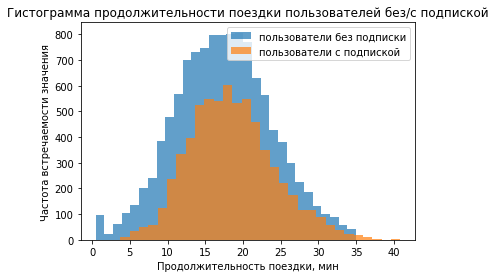

In [20]:
plt.hist(data_free['duration'], bins=30, alpha=0.7, label='пользователи без подписки')
plt.hist(data_ultra['duration'], bins=30, alpha=0.7, label='пользователи с подпиской')
plt.xlabel('Продолжительность поездки, мин')
plt.ylabel('Частота встречаемости значения')
plt.legend()
plt.title('Гистограмма продолжительности поездки пользователей без/с подпиской')
print('Пользователи без подписки:\n', data_free['duration'].describe())
print('Пользователи с подпиской:\n',  data_ultra['duration'].describe())

Из гистограмм распределения и с данных из сводной статистики можно заметить, что медианное и среднее значение продолжительности поездки пользователей без/с подпиской примерно одинаковы. Среднее значение составляет примерно 18 минут, медианное - 18 минут.

Пользователи без подписки:
 count    11568.000000
mean      3045.495282
std       1246.173806
min          0.855683
25%       2366.562689
50%       3114.648465
75%       3905.697894
max       7211.007745
Name: distance, dtype: float64
Пользователи с подпиской:
 count    6500.000000
mean     3115.445388
std       836.895330
min       244.210438
25%      2785.444017
50%      3148.637229
75%      3560.574425
max      5699.769662
Name: distance, dtype: float64


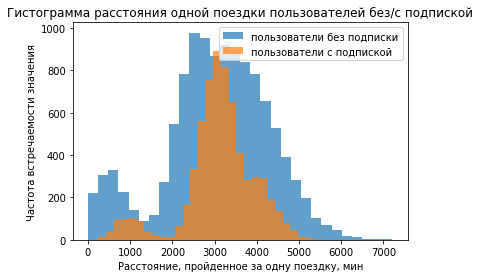

In [21]:
plt.hist(data_free['distance'], bins=30, alpha=0.7, label='пользователи без подписки')
plt.hist(data_ultra['distance'], bins=30, alpha=0.7, label='пользователи с подпиской')
plt.xlabel('Расстояние, пройденное за одну поездку, мин')
plt.ylabel('Частота встречаемости значения')
plt.legend()
plt.title('Гистограмма расстояния одной поездки пользователей без/с подпиской')
print('Пользователи без подписки:\n', data_free['distance'].describe())
print('Пользователи с подпиской:\n',  data_ultra['distance'].describe())

Из гистограмм распределения и с данных из сводной статистики можно заметить, что среднее и медианное расстояние, пройденное за одну поездку, у пользователей с подпиской больше, чем у пользователей без полписки. Среднее пройденное расстояние пользователей без подписки - 3045 м, пользователей с подпиской - 3115 м.

#### Шаг 5. Подсчёт выручки

In [22]:
data['duration'] = np.ceil(data['duration']).astype('int')
data_sum = data.pivot_table(index=['user_id', 'month'], values=['duration', 'distance', 'age', 'minute_price', 'start_ride_price', 'subscription_fee'],\
aggfunc={'duration': 'sum', 'distance':'sum','age': 'count', 'minute_price': 'mean', 'start_ride_price':'mean', 'subscription_fee':'mean'})
data_sum = data_sum.rename(columns={'duration':'суммарное время', 'distance':'суммарное расстояние', 'age':'количество поездок'})
data_sum = data_sum.reset_index()
data_sum.isna().sum()

user_id                 0
month                   0
количество поездок      0
суммарное расстояние    0
суммарное время         0
minute_price            0
start_ride_price        0
subscription_fee        0
dtype: int64

In [23]:
data_sum['помесячная выручка'] = data_sum['start_ride_price'] * data_sum['количество поездок'] \
+ data_sum['minute_price'] * data_sum['суммарное время'] + data_sum['subscription_fee']
print(data_sum['помесячная выручка'].sum())
data_sum.head()

3878641


,user_id,month,количество поездок,суммарное расстояние,суммарное время,minute_price,start_ride_price,subscription_fee,помесячная выручка
0,1,1,2,7027.511294,42,6,0,199,451
1,1,4,1,754.159807,7,6,0,199,241
2,1,8,2,6723.470560,46,6,0,199,475
3,1,10,2,5809.911100,32,6,0,199,391
4,1,11,3,7003.499363,56,6,0,199,535


Создан дополнительный столбец в таблице "помесячная выручка", в ней посчитана выручка за каждый месяц от каждого отдельного пользователя. Итоговая выручка составила 3878641

#### Шаг 6. Проверка гипотез

6.1. Проверяем следующие гипотезы:
- нулевая гипотеза: средние значения продолжительности поездки пользователей без/с подпиской равны
- альтернативная гипотеза: среднее значение продолжительности поездки пользователей с подпиской больше, чем у пользователей без подписки

In [25]:
alpha = 0.05 #уровень статистической значимости
results1 = st.ttest_ind(data_ultra['duration'], data_free['duration'], alternative='greater')
print(f'p-value: {results1.pvalue}')
if results1.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-value: 1.2804098316645618e-34
Отвергаем нулевую гипотезу


In [26]:
print('Средняя продолжительность одной поездки пользователей без подписки', data_free['duration'].mean())
print('Средняя продолжительность одной поездки пользователей с подпиской', data_ultra['duration'].mean())

Средняя продолжительность одной поездки пользователей без подписки 17.39090929866399
Средняя продолжительность одной поездки пользователей с подпиской 18.54198516280583


В результате t-теста можно сделать вывод, что альтернативная гипотеза не отвергается: среднее значение продолжительности поездки пользователей с подпиской больше, чем у пользователей без подписки. Также дополнительно было выведено значение p-value - оно очень мало, соответственно, даже если взять уровень статистической значемости менее 5%, то результат останется тем же.

6.2 Проверяем следующие гипотезы:
- нулевая: среднее расстояние, пройденное за одну поездку, не превышает 3130 м
- альтернативная: среднее расстояние, пройденное за одну поездку, больше 3130 м

In [27]:
distance = 3130
alpha = 0.05
results2 = st.ttest_1samp(data_ultra['distance'], distance, alternative='greater')
print(f'p-value: {results2.pvalue}')
if results2.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-value: 0.9195368847849785
Нет оснований отвергнуть нулевую гипотезу


В результате t-теста можно сделать вывод, что нулевая гипотеза не отвергается: среднее расстояние, пройденное за одну поездку пользователем с подпиской, не превышает 3130 м. 

6.3 Проверяем следующие гипотезы:
- нулевая: помесячная выручка от пользователей с подпиской равна помесячной выручке пользавателей без подписки
- альтернативная: помесячная выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки

In [28]:
data_free_sum = data_sum.query('subscription_fee == 0')
data_ultra_sum = data_sum.query('subscription_fee == 199')
alpha = 0.05
results3 = st.ttest_ind(data_ultra_sum['помесячная выручка'], data_free_sum['помесячная выручка'], \
alternative='greater')
print(f'p-value: {results3.pvalue}')
if results3.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-value: 1.8850394384715216e-31
Отвергаем нулевую гипотезу


В результате t-теста можно сделать вывод, что альтернативная гипотеза не отвергается: помесячная выручка от пользователей с подпиской выше.

6.4 Для проверки гипотезы о количестве обращений пользователей после обновления серверов необходим метод scipy.stats.ttest_rel(), так как в данном случае рассматриваются зависимые выборки. В качестве параметров передаются генеральные совокупности (или случайные выборки) до и после обновления серверов, параметр alternative='greater'.
Для данного случая можно сформулировать следующие гипотезы:
- нулевая: количество обращений с обновлением серверов не изменилось;
- альтернативная: количество обращений с обновлением серверов стало меньше.

#### Шаг 7. Распределения

/opt/conda/lib/python3.9/site-packages/scipy/stats/_discrete_distns.py:78: RuntimeWarning: divide by zero encountered in _binom_pdf
  return _boost._binom_pdf(x, n, p)


0.0505235199072141

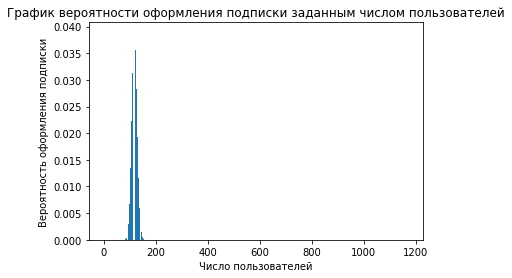

In [29]:
n = 1171
p = 0.1
x = 100
distr1 = st.binom(n, p)
distr = []
for k in range(0, n + 1):
    current_value = st.binom.pmf(k, n, p)
    distr.append(current_value)
plt.bar(range(0, n + 1), distr)
plt.xlabel('Число пользователей')
plt.ylabel('Вероятность оформления подписки')
plt.title('График вероятности оформления подписки заданным числом пользователей')
result = distr1.cdf(x)
result

В задаче величина описывается биноминальным распределением (так как нужно получить конкретное количество промокодов, то аппроксимировать нормальным распределением не нужно). В результате подбора такого значения числа промокодов, при котором вероятность не выполнить план составляет примерно 5%, было получено число 1171.

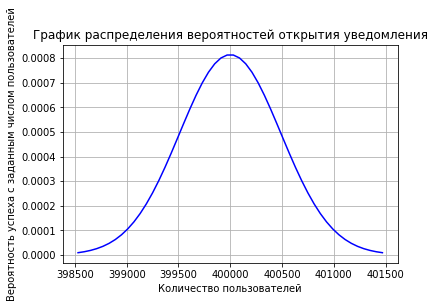

Вероятность того, что уведомление откроют не более 399,5 тыс. пользователей: 0.15371708296369768


In [30]:
p = 0.4
n = 1000000
mu = n * p
sigma = math.sqrt(n * p * (1 - p))
distr = st.norm(mu, sigma)
result = distr.cdf(399500)
x = np.linspace(mu - 3 * sigma, mu + 3 * sigma)
pdf_values = distr.pdf(x)
plt.plot(x, pdf_values, color='blue')
plt.grid(True)
plt.xlabel('Количество пользователей')
plt.ylabel('Вероятность успеха с заданным числом пользователей')
plt.title('График распределения вероятностей открытия уведомления')
plt.show()
print('Вероятность того, что уведомление откроют не более 399,5 тыс. пользователей:', result)

#### Шаг 8. Общий вывод

В качестве исходных данных были переданы таблицы с данными о пользователях, поездках, типах подписок. В ходе исследования данные были объединены в одну таблицу data, затем  разделены на пользователей с подпиской (data_ultra и без подписки data_free. После каждого объединения/разделения датафреймы были проверены на наличие пропусков. (Пропусков не оказалось)

**В исходных данных были следующие проблемы:**
- явные дубликаты в таблице с пользователями
- неверный тип данных (в столбце date таблицы с поездками тип данных object был изменен на datetime)

**В результате анализа были изучены следующие зависимости:**
- больше всего зарегистрированных пользователей из Пятигорска, Екатеринбурга, Ростова-на-Дону, меньше всего - из Москвы. Возможно, это связано с тем, что в Москве есть более распространенные сервисы аренды самокатов.
- пользователей с подпиской и без примерно одинаковое соотношение (~54% без подписки, ~46% с подпиской). Пользователей без подписки больше, так как скорее всего люди не считают, что с подпиской аренда будет выгоднее.
- большинство пользователей - молодые люди возрастом от 23 до 27 лет, максимальный возраст - 43 года, минимальный - 12 лет.
- средняя дистанция одной поездки - примерно 3000 м, средняя продолжительность - 18 мин.
- средняя продолжительность поездки пользователей с подпиской больше, чем без подписки
- среднее пройденное расстояние пользователей с подпиской не превышает 3130 м, что является оптимальным с точки зрения износа самоката
- помесячная выручка от пользователей с подпиской выше, чем от пользователей без подписки, это говорит о том, что привлекать пользователей оформлять подписку выгодно для компании
- была посчитана общая выручка компании - она составила 3878641р

**Рекомендации:**
- необходимо привлекать пользователей оформлять подписку, тк пользователи с подпиской приносят больше выручки в компанию
- необходимо изучить рынок в Москве и увеличить количество зарегистрированных пользователей
- необходимо проверить работу программы, фиксирующей время поездки на самокате (тк в датафрейме встречались аномальные значения - 0.5 минут)
- необходимо установить минимальный возраст для регистрации пользователей (в датафрейме встречались пользователи младше 14 лет, что запрещено)